# CLIP Supplementary Evaluation

This notebook performs CLIP-based supplementary evaluation for style relearning.

Goal:
- compare original, unlearned, and relearned_150 outputs
- measure similarity to Van Gogh-style prompts
- measure similarity to generic painting prompts
- compute style specificity

In [2]:
!pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


In [3]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import open_clip

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
MY_EVAL_DIR = "/content/drive/MyDrive/style_relearning_eval"
RESULT_PATH = f"{MY_EVAL_DIR}/clip_supplementary_results.csv"
PAIR_PATH = f"{MY_EVAL_DIR}/evaluation_pairs_blind_template.csv"

pair_df = pd.read_csv(PAIR_PATH)
pair_df.head()
clip_df = pd.read_csv(RESULT_PATH)
clip_df.head()

,image_idx,original_path,unlearned_path,relearned_150_path,original_vg_similarity,original_generic_similarity,original_style_specificity,unlearned_vg_similarity,unlearned_generic_similarity,unlearned_style_specificity,relearned_150_vg_similarity,relearned_150_generic_similarity,relearned_150_style_specificity
0,0.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.313011,0.272656,0.040354,0.289552,0.276193,0.013358,0.271984,0.273506,-0.001521
1,1.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.271554,0.256700,0.014854,0.243729,0.263675,-0.019946,0.263139,0.263317,-0.000179
2,2.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.287813,0.276855,0.010958,0.261639,0.272155,-0.010516,0.293208,0.276465,0.016743
3,3.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.303425,0.268898,0.034527,0.244546,0.271460,-0.026914,0.255919,0.273406,-0.017487
4,4.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.283964,0.261442,0.022522,0.292793,0.283377,0.009416,0.274286,0.262194,0.012092


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model_name = "ViT-B-32"
pretrained_name = "openai"

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name,
    pretrained=pretrained_name,
    device=device
)
tokenizer = open_clip.get_tokenizer(model_name)
model.eval()

device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [9]:
VG_PROMPTS = [
    "a painting in the style of Vincent van Gogh",
    "a post-impressionist oil painting in the style of Vincent van Gogh",
    "thick expressive brushstrokes and bold complementary colors, Vincent van Gogh style"
]

GENERIC_PAINTING_PROMPTS = [
    "a painting",
    "an oil painting",
    "a post-impressionist painting"
]

In [10]:
with torch.no_grad():
    text_tokens = tokenizer(VG_PROMPTS + GENERIC_PAINTING_PROMPTS).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

vg_text_features = text_features[:len(VG_PROMPTS)]
generic_text_features = text_features[len(VG_PROMPTS):]

def encode_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features

def clip_score_image(image_path):
    image_features = encode_image(image_path)

    vg_score = (image_features @ vg_text_features.T).mean().item()
    generic_score = (image_features @ generic_text_features.T).mean().item()
    specificity = vg_score - generic_score

    return vg_score, generic_score, specificity

In [11]:
clip_df = pair_df[["image_idx", "original_path", "unlearned_path", "relearned_150_path"]].copy()

for prefix, path_col in [
    ("original", "original_path"),
    ("unlearned", "unlearned_path"),
    ("relearned_150", "relearned_150_path")
]:
    vg_scores = []
    generic_scores = []
    specificity_scores = []

    for path in clip_df[path_col]:
        vg, generic, spec = clip_score_image(path)
        vg_scores.append(vg)
        generic_scores.append(generic)
        specificity_scores.append(spec)

    clip_df[f"{prefix}_vg_similarity"] = vg_scores
    clip_df[f"{prefix}_generic_similarity"] = generic_scores
    clip_df[f"{prefix}_style_specificity"] = specificity_scores

clip_df.head()

,image_idx,original_path,unlearned_path,relearned_150_path,original_vg_similarity,original_generic_similarity,original_style_specificity,unlearned_vg_similarity,unlearned_generic_similarity,unlearned_style_specificity,relearned_150_vg_similarity,relearned_150_generic_similarity,relearned_150_style_specificity
0,0.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.313011,0.272656,0.040354,0.289552,0.276193,0.013358,0.271984,0.273506,-0.001521
1,1.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.271554,0.256700,0.014854,0.243729,0.263675,-0.019946,0.263139,0.263317,-0.000179
2,2.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.287813,0.276855,0.010958,0.261639,0.272155,-0.010516,0.293208,0.276465,0.016743
3,3.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.303425,0.268898,0.034527,0.244546,0.271460,-0.026914,0.255919,0.273406,-0.017487
4,4.0,/content/drive/MyDrive/evaluation/original-150...,/content/drive/MyDrive/evaluation/unlearned-15...,/content/drive/MyDrive/evaluation/relearned-15...,0.283964,0.261442,0.022522,0.292793,0.283377,0.009416,0.274286,0.262194,0.012092


In [12]:
labels = ["original", "unlearned", "relearned_150"]

vg_means = [
    clip_df["original_vg_similarity"].mean(),
    clip_df["unlearned_vg_similarity"].mean(),
    clip_df["relearned_150_vg_similarity"].mean()
]

spec_means = [
    clip_df["original_style_specificity"].mean(),
    clip_df["unlearned_style_specificity"].mean(),
    clip_df["relearned_150_style_specificity"].mean()
]

print("Van Gogh similarity means:")
for label, val in zip(labels, vg_means):
    print(label, round(val, 4))

print("\nStyle specificity means:")
for label, val in zip(labels, spec_means):
    print(label, round(val, 4))

Van Gogh similarity means:
original 0.3011
unlearned 0.2536
relearned_150 0.2662

Style specificity means:
original 0.0354
unlearned -0.0008
relearned_150 0.0039


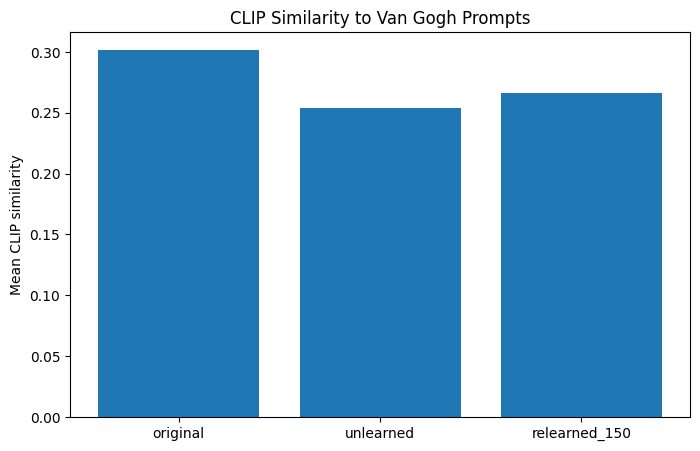

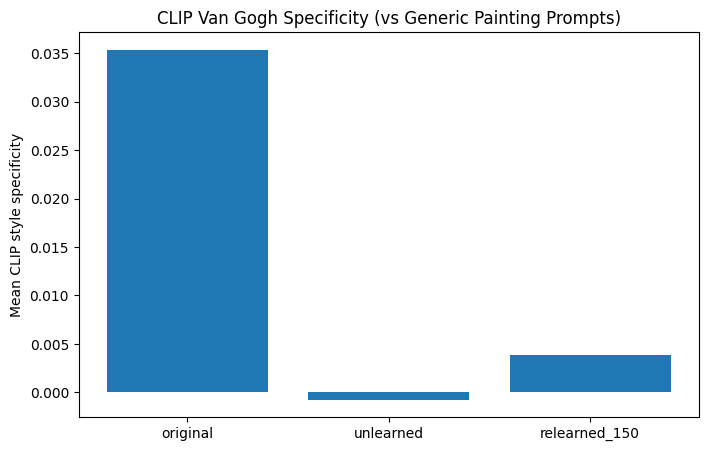

In [13]:
FIG_DIR = f"{MY_EVAL_DIR}/final_figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.bar(labels, vg_means)
plt.ylabel("Mean CLIP similarity")
plt.title("CLIP Similarity to Van Gogh Prompts")
plt.savefig(f"{FIG_DIR}/clip_similarity_van_gogh.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.bar(labels, spec_means)
plt.ylabel("Mean CLIP style specificity")
plt.title("CLIP Van Gogh Specificity (vs Generic Painting Prompts)")
plt.savefig(f"{FIG_DIR}/clip_specificity_van_gogh.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [14]:
RESULT_PATH = f"{MY_EVAL_DIR}/clip_supplementary_results.csv"
clip_df.to_csv(RESULT_PATH, index=False)
print("Saved to:", RESULT_PATH)

Saved to: /content/drive/MyDrive/style_relearning_eval/clip_supplementary_results.csv
